
# 02 — Exploratory Data Analysis (Hydraulic Condition Monitoring)

**Goal.** Perform fast, reproducible EDA using the processed artifacts from **01 — Load Data**  
with robust fallbacks if those files don't exist yet.

**What this notebook does**
- Loads `X` and `y` from `data/processed/` (or regenerates via `utils/data_io.py` if missing)
- Summarizes dataset shape, memory, and basic stats
- Shows **label distributions** (cooler/valve/leakage/accumulator/stable_flag)
- Checks **missing values** and basic **feature variance**
- Plots a few **sample sensor signals** for sanity
- Produces a lightweight **correlation heatmap** on a feature subset
- Saves small EDA artifacts to `data/metadata/`


In [1]:

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Python can import from the repo root (where utils/ lives)
repo_root = Path.cwd()
if not (repo_root / "utils" / "data_io.py").exists():
    repo_root = Path.cwd().parents[0]  # e.g., notebooks/ -> repo root
sys.path.insert(0, str(repo_root))

from utils.data_io import (
    ensure_dirs, load_profile, load_all_sensors,
    build_feature_matrix, save_processed, write_feature_index,
    ROOT_DIR, META_DIR, PROC_DIR
)

ensure_dirs()
print("ROOT_DIR:", ROOT_DIR)
print("PROC_DIR:", PROC_DIR)
print("META_DIR:", META_DIR)


ROOT_DIR: C:\Users\melny\OneDrive\Desktop\Projects\hydraulic_dashboard
PROC_DIR: C:\Users\melny\OneDrive\Desktop\Projects\hydraulic_dashboard\data\processed
META_DIR: C:\Users\melny\OneDrive\Desktop\Projects\hydraulic_dashboard\data\metadata



## Load processed artifacts (fallback to regeneration)

Tries to read `data/processed/X_features.parquet` and `y_labels.parquet`.  
If not found, it rebuilds them using `utils/data_io.py` (same logic as notebook 01).


In [2]:

X_path_pq = PROC_DIR / "X_features.parquet"
y_path_pq = PROC_DIR / "y_labels.parquet"
X_path_csv = PROC_DIR / "X_features.csv"
y_path_csv = PROC_DIR / "y_labels.csv"

def _load_processed_or_rebuild():
    # Try Parquet first
    if X_path_pq.exists() and y_path_pq.exists():
        X = pd.read_parquet(X_path_pq)
        y = pd.read_parquet(y_path_pq)
        print("✅ Loaded processed Parquet artifacts.")
        return X, y
    # Try CSV fallback
    if X_path_csv.exists() and y_path_csv.exists():
        X = pd.read_csv(X_path_csv)
        y = pd.read_csv(y_path_csv)
        print("✅ Loaded processed CSV artifacts.")
        return X, y
    # Rebuild if nothing exists
    print("⚠️ Processed artifacts not found. Rebuilding from raw via utils/data_io.py...")
    labels = load_profile()
    frames, order = load_all_sensors()
    X, y = build_feature_matrix(frames, order, labels)
    save_processed(X, y)
    write_feature_index(X)
    return X, y

X, y = _load_processed_or_rebuild()
X.shape, y.shape


✅ Loaded processed Parquet artifacts.


((2205, 43680), (2205, 5))


## Dataset overview


In [3]:

def dataframe_memory_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Rows: {X.shape[0]:,} | Features: {X.shape[1]:,}")
print(f"X memory ~ {dataframe_memory_mb(X):.2f} MB, y memory ~ {dataframe_memory_mb(y):.2f} MB")
print("y columns:", list(y.columns))


Rows: 2,205 | Features: 43,680
X memory ~ 734.82 MB, y memory ~ 0.08 MB
y columns: ['cooler_condition', 'valve_condition', 'internal_pump_leakage', 'hydraulic_accumulator', 'stable_flag']



## Label distributions



cooler_condition distribution:
 cooler_condition
3      732
20     732
100    741
Name: count, dtype: int64

valve_condition distribution:
 valve_condition
73      360
80      360
90      360
100    1125
Name: count, dtype: int64

internal_pump_leakage distribution:
 internal_pump_leakage
0    1221
1     492
2     492
Name: count, dtype: int64

hydraulic_accumulator distribution:
 hydraulic_accumulator
90     808
100    399
115    399
130    599
Name: count, dtype: int64

stable_flag distribution:
 stable_flag
0    1449
1     756
Name: count, dtype: int64


5

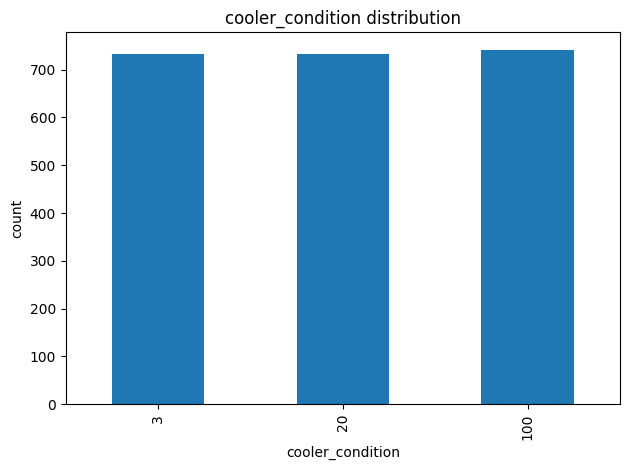

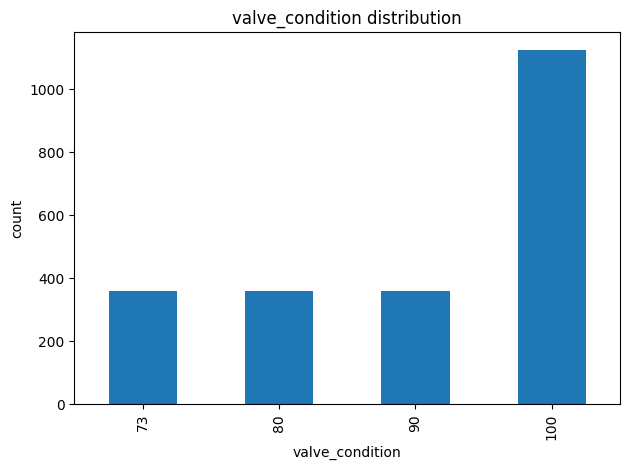

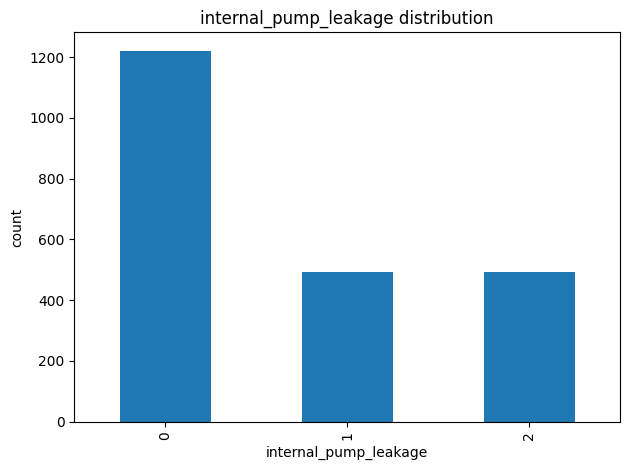

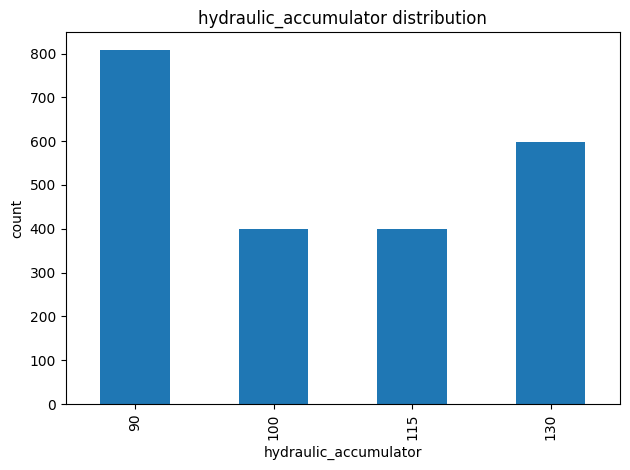

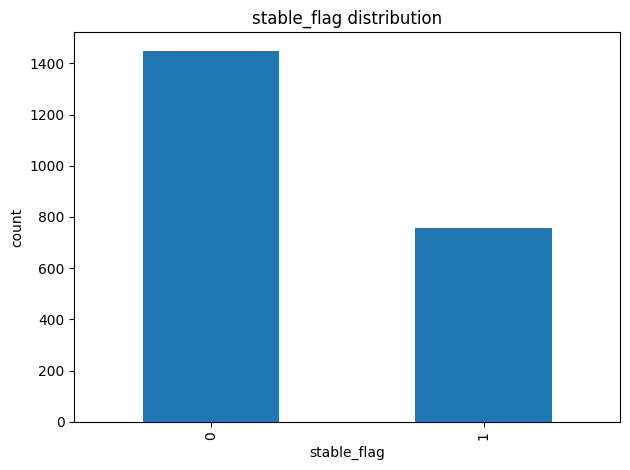

In [4]:

figures = []
for col in y.columns:
    vc = y[col].value_counts(dropna=False).sort_index()
    print(f"\n{col} distribution:\n", vc)
    plt.figure()
    vc.plot(kind="bar")
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    figures.append(col)
len(figures)



## Missing values & basic stats


In [5]:

# Missing values summary
total_missing = X.isna().sum().sum()
cols_with_na = X.columns[X.isna().any()].tolist()
print(f"Total missing values in X: {int(total_missing):,}")
print(f"Columns with missing values: {len(cols_with_na)}")

# Basic stats on a sample (to avoid huge prints)
sample_cols = X.columns[:50]  # first 50 features for a quick snapshot
display(X[sample_cols].describe().T.head(20))


Total missing values in X: 0
Columns with missing values: 0


,count,mean,std,min,25%,50%,75%,max
CE_t1,2205.0,31.325613,11.532175,17.356,20.165,27.334,46.651,48.136
CE_t2,2205.0,31.364606,11.512519,17.552,20.260,27.397,46.675,48.057
CE_t3,2205.0,31.395767,11.504075,17.440,20.333,27.446,46.690,48.124
CE_t4,2205.0,31.402451,11.504153,17.416,20.387,27.455,46.686,48.112
CE_t5,2205.0,31.395373,11.521065,17.392,20.367,27.424,46.693,48.159
CE_t6,2205.0,31.371016,11.539150,17.404,20.328,27.384,46.686,48.253
CE_t7,2205.0,31.351265,11.566626,17.456,20.240,27.356,46.711,48.158
CE_t8,2205.0,31.339065,11.579167,17.396,20.149,27.351,46.698,48.219
CE_t9,2205.0,31.307852,11.571700,17.506,20.113,27.351,46.678,48.146
CE_t10,2205.0,31.238561,11.538494,17.364,20.071,27.313,46.544,48.040



## High-variance features (top 25)


,variance
EPS1_t993,23158.332231
EPS1_t994,23154.994692
EPS1_t992,23067.388871
EPS1_t995,23039.983589
EPS1_t996,23000.635423
EPS1_t991,22868.443996
EPS1_t997,22818.445205
EPS1_t998,22681.719459
EPS1_t990,22546.537567
EPS1_t999,22354.265655


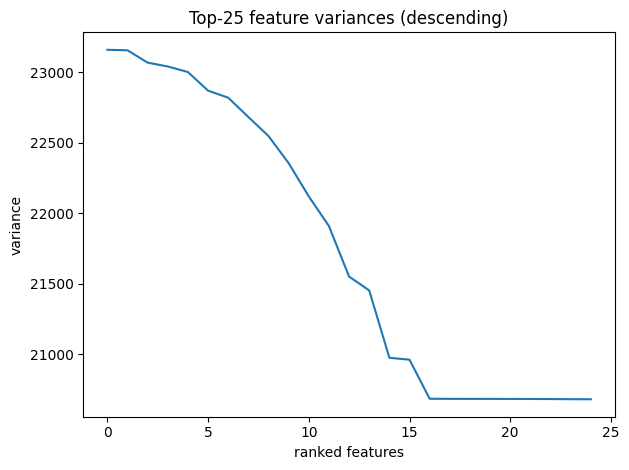

In [6]:

variances = X.var().sort_values(ascending=False)
top_vars = variances.head(25)
display(top_vars.to_frame("variance"))

plt.figure()
plt.plot(top_vars.values)
plt.title("Top-25 feature variances (descending)")
plt.xlabel("ranked features")
plt.ylabel("variance")
plt.tight_layout()



## Sensor group summaries (from `feature_index.csv`)

If available, this summarizes per-group feature counts and mean variance.


In [7]:

idx_path = META_DIR / "feature_index.csv"
if idx_path.exists():
    idx = pd.read_csv(idx_path)
    # Compute variance per feature and join
    var_df = variances.rename("variance").to_frame().reset_index().rename(columns={"index":"column"})
    idx2 = idx.merge(var_df, on="column", how="left")
    group_stats = idx2.groupby("group").agg(
        n_features=("column","count"),
        mean_variance=("variance","mean")
    ).sort_values("n_features", ascending=False)
    display(group_stats)

    # Save group stats for docs
    out_group = META_DIR / "group_stats.csv"
    group_stats.to_csv(out_group)
    print("Saved group stats ->", out_group)
else:
    print("feature_index.csv not found; run write_feature_index(X) in notebook 01 if needed.")


,n_features,mean_variance
group,,
pressure,36000,24.451479
electrical,6060,10699.207532
flow,1200,1.351924
temperature,240,59.965962
cooler,120,67.076346
vibration,60,0.005174


Saved group stats -> C:\Users\melny\OneDrive\Desktop\Projects\hydraulic_dashboard\data\metadata\group_stats.csv



## Sample sensor signals

Quick plots of the first 500 rows for a few representative sensors (if present).


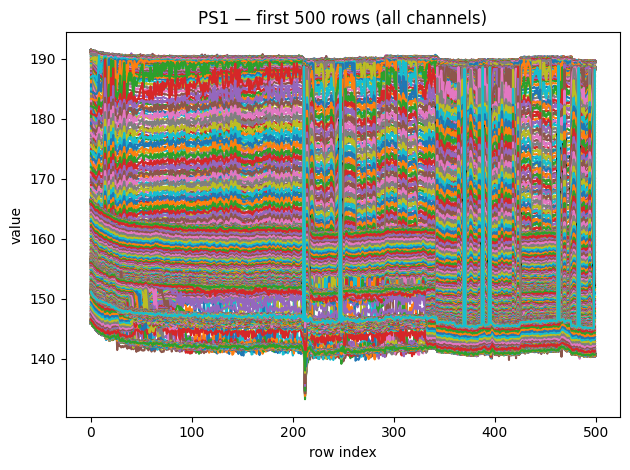

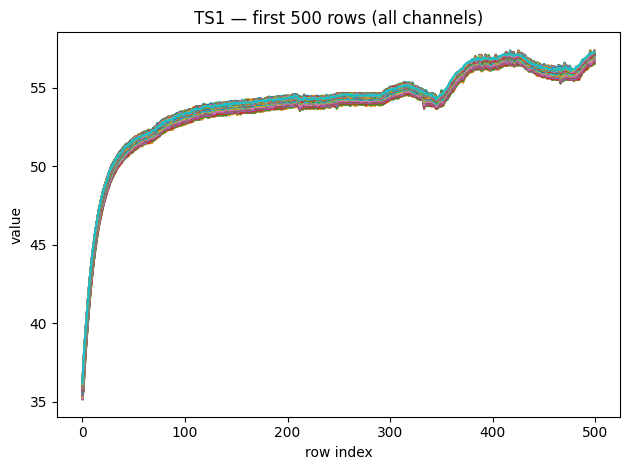

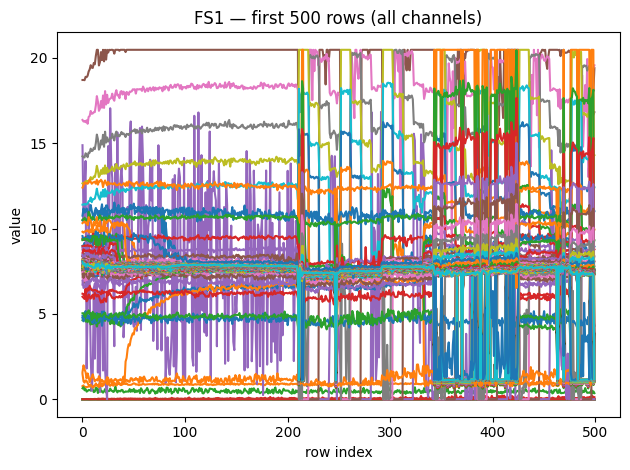

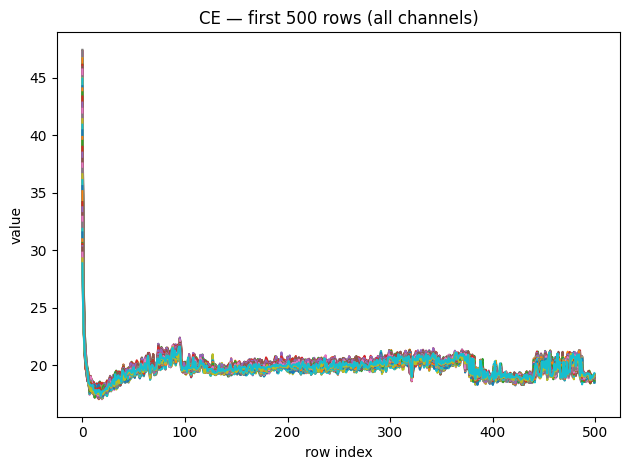

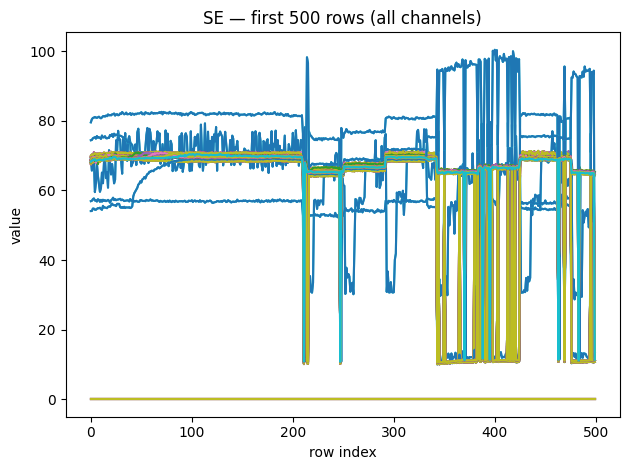

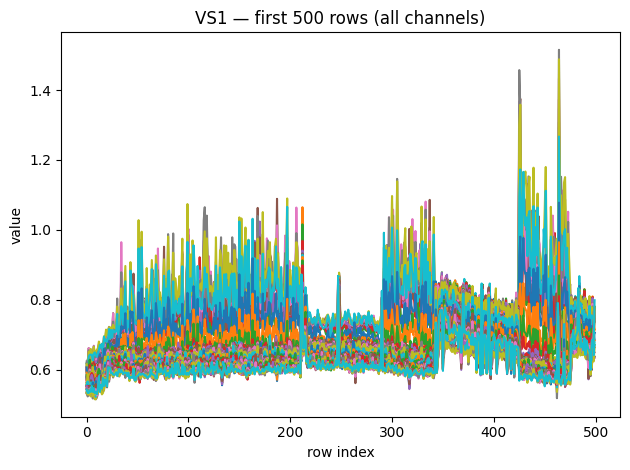

In [8]:

def plot_sensor_series(prefix: str, n_points: int = 500):
    cols = [c for c in X.columns if c.startswith(prefix + "_")]
    if not cols:
        print(f"No columns found for sensor {prefix}")
        return
    s = X[cols].iloc[:n_points]
    plt.figure()
    plt.plot(s.index, s.values)
    plt.title(f"{prefix} — first {n_points} rows (all channels)")
    plt.xlabel("row index")
    plt.ylabel("value")
    plt.tight_layout()

for sensor in ["PS1", "TS1", "FS1", "CE", "SE", "VS1"]:
    plot_sensor_series(sensor)



## Correlation heatmap (feature subset)

To keep things lightweight, we compute correlations on a small subset of features.


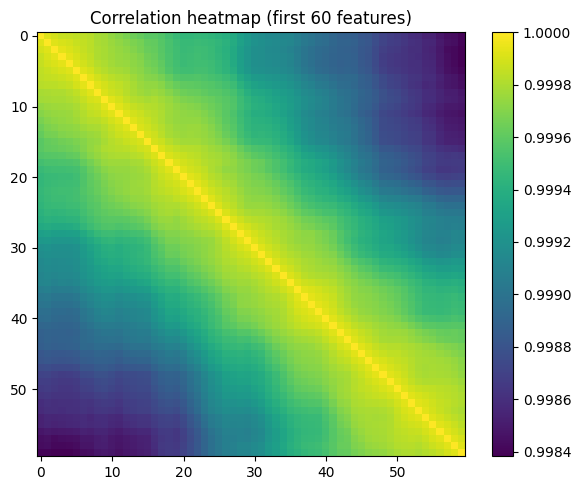

In [9]:

subset_cols = list(X.columns[:60])  # first 60 columns for a compact heatmap
corr = X[subset_cols].corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, aspect="auto")
plt.title("Correlation heatmap (first 60 features)")
plt.colorbar()
plt.tight_layout()



## Save EDA artifacts


In [10]:

META_DIR.mkdir(parents=True, exist_ok=True)

# Save label distributions
label_counts = {col: y[col].value_counts(dropna=False) for col in y.columns}
label_df = pd.concat(label_counts, axis=1).fillna(0).astype(int)
label_out = META_DIR / "label_distributions.csv"
label_df.to_csv(label_out)

# Save top variance list
top_vars_out = META_DIR / "top_variance_features.csv"
top_vars.to_frame("variance").to_csv(top_vars_out)

print("Saved:")
print(" -", label_out)
print(" -", top_vars_out)


Saved:
 - C:\Users\melny\OneDrive\Desktop\Projects\hydraulic_dashboard\data\metadata\label_distributions.csv
 - C:\Users\melny\OneDrive\Desktop\Projects\hydraulic_dashboard\data\metadata\top_variance_features.csv



## Summary

- Loaded `X` and `y` (processed) with robust fallbacks
- Reviewed shapes, memory footprint, and quick stats
- Visualized label distributions and sample sensor traces
- Checked missing values and identified high-variance features
- Created correlation heatmap on a subset for a fast sanity check
- Saved useful EDA artifacts into `data/metadata/` for documentation
